# Feature Audit

In [2]:
INPUT_PATH = "dataset2_cleaned.csv"
OUTPUT_PATH  = "dataset2_audit.csv"
AUDIT_TABLE_PATH = "feature_audit_table.csv"
TARGET_COL = None

In [3]:
import pandas as pd

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)

df = pd.read_csv(INPUT_PATH)
print(f"Dataset dimuat: {df.shape[0]} baris, {df.shape[1]} kolom")

if TARGET_COL is None:
    candidate_names = ["label", "Label", "class", "Class", "type", "Type",
                        "target", "Target", "phishing", "Phishing", "y", "Result", "result"]
    found = [c for c in candidate_names if c in df.columns]
    if found:
        TARGET_COL = found[0]
        print(f"Kolom target terdeteksi otomatis: '{TARGET_COL}'")

assert TARGET_COL is not None and TARGET_COL in df.columns, \
    "TARGET_COL belum valid. Isi manual di cell konfigurasi."

feature_cols = [c for c in df.columns if c != TARGET_COL]
print(f"Jumlah fitur yang akan diaudit: {len(feature_cols)}")


Dataset dimuat: 51401 baris, 83 kolom
Kolom target terdeteksi otomatis: 'phishing'
Jumlah fitur yang akan diaudit: 82


In [4]:
EXTERNAL_KEYWORDS = [
    "whois", "registration", "domain_age", "age_of_domain", "age_domain",
    "dns", "dns_record",
    "google_index", "page_rank", "pagerank", "web_traffic", "alexa", "traffic_rank",
    "ssl", "tls", "certificate", "cert_",
    "asn", "ip_owner", "geo", "geolocation",
    "statistical_report", "blacklist",
]

CONTENT_KEYWORDS = [
    "hyperlink", "link", "iframe", "form", "login_form", "favicon", "anchor",
    "media", "css", "redirection", "redirect", "popup", "mouseover", "onmouseover",
    "right_clic", "right_click", "title", "copyright", "submit_email", "sfh",
    "external", "internal", "html", "dom", "script", "meta",
]

def categorize_feature(col_name: str) -> str:
    name_lower = col_name.lower()
    if any(kw in name_lower for kw in EXTERNAL_KEYWORDS):
        return "C - External service dependent"
    if any(kw in name_lower for kw in CONTENT_KEYWORDS):
        return "B - Content/HTML-based"
    return "A - URL-only / Lexical"

audit_records = []
for col in feature_cols:
    category = categorize_feature(col)
    default_keep = category != "C - External service dependent"
    audit_records.append({
        "feature": col,
        "auto_category": category,
        "default_decision": "Keep" if default_keep else "Remove",
        "reason": ""
    })

audit_df = pd.DataFrame(audit_records)
print("Ringkasan auto-kategorisasi:")
print(audit_df["auto_category"].value_counts())
print()
audit_df

Ringkasan auto-kategorisasi:
auto_category
A - URL-only / Lexical            72
B - Content/HTML-based             8
C - External service dependent     2
Name: count, dtype: int64



,feature,auto_category,default_decision,reason
0,qty_dot_url,A - URL-only / Lexical,Keep,
1,qty_hyphen_url,A - URL-only / Lexical,Keep,
2,qty_underline_url,A - URL-only / Lexical,Keep,
3,qty_slash_url,A - URL-only / Lexical,Keep,
4,qty_equal_url,A - URL-only / Lexical,Keep,
5,qty_at_url,A - URL-only / Lexical,Keep,
6,qty_and_url,A - URL-only / Lexical,Keep,
7,qty_percent_url,A - URL-only / Lexical,Keep,
8,qty_tld_url,A - URL-only / Lexical,Keep,
9,length_url,A - URL-only / Lexical,Keep,


In [5]:
display(audit_df[audit_df["auto_category"] == "C - External service dependent"])


,feature,auto_category,default_decision,reason
73,asn_ip,C - External service dependent,Remove,
80,tls_ssl_certificate,C - External service dependent,Remove,


In [6]:
display(audit_df[audit_df["auto_category"] == "B - Content/HTML-based"])

,feature,auto_category,default_decision,reason
10,qty_dot_domain,B - Content/HTML-based,Keep,
11,qty_hyphen_domain,B - Content/HTML-based,Keep,
12,qty_vowels_domain,B - Content/HTML-based,Keep,
13,domain_length,B - Content/HTML-based,Keep,
72,domain_spf,B - Content/HTML-based,Keep,
74,time_domain_activation,B - Content/HTML-based,Keep,
75,time_domain_expiration,B - Content/HTML-based,Keep,
81,qty_redirects,B - Content/HTML-based,Keep,


In [7]:
#  REVIEW

MANUAL_OVERRIDE = {

    # URL Parsing Features (KEEP)

    "port": (
        "Keep",
        "Nomor port dapat diparsing langsung dari URL tanpa memerlukan request eksternal."
    ),

    "domain_in_ip": (
        "Keep",
        "Dapat ditentukan langsung dari hostname pada URL."
    ),

    "url_shortened": (
        "Keep",
        "Dapat dideteksi menggunakan daftar domain URL shortener secara lokal."
    ),
    # External Dependency (REMOVE)
    "time_response": (
        "Remove",
        "Memerlukan koneksi HTTP untuk mengukur response time."
    ),

    "asn_ip": (
        "Remove",
        "Memerlukan lookup ASN melalui DNS atau layanan eksternal."
    ),

    "qty_ip_resolved": (
        "Remove",
        "Memerlukan proses DNS resolution."
    ),

    "qty_nameservers": (
        "Remove",
        "Memerlukan query DNS."
    ),

    "ttl_hostname": (
        "Remove",
        "Memerlukan DNS lookup."
    ),

    "tls_ssl_certificate": (
        "Remove",
        "Memerlukan TLS handshake dengan server."
    ),

    "domain_spf": (
        "Remove",
        "Memerlukan query DNS TXT record."
    ),

    "time_domain_activation": (
        "Remove",
        "Memerlukan data WHOIS."
    ),

    "time_domain_expiration": (
        "Remove",
        "Memerlukan data WHOIS."
    ),

    "url_google_index": (
        "Remove",
        "Memerlukan layanan Google Index yang tidak tersedia saat inferensi."
    ),

    "domain_google_index": (
        "Remove",
        "Memerlukan layanan Google Index yang tidak tersedia saat inferensi."
    )
}

for feat, (decision, reason) in MANUAL_OVERRIDE.items():

    if feat in audit_df["feature"].values:

        audit_df.loc[
            audit_df["feature"] == feat,
            "default_decision"
        ] = decision

        audit_df.loc[
            audit_df["feature"] == feat,
            "reason"
        ] = reason

    else:

        print(f"[WARNING] Feature '{feat}' tidak ditemukan.")

[WARNING] Feature 'port' tidak ditemukan.
[WARNING] Feature 'domain_in_ip' tidak ditemukan.
[WARNING] Feature 'url_shortened' tidak ditemukan.
[WARNING] Feature 'url_google_index' tidak ditemukan.
[WARNING] Feature 'domain_google_index' tidak ditemukan.


In [8]:
final_audit_table = audit_df.rename(columns={
    "feature": "Feature",
    "auto_category": "Kategori",
    "default_decision": "Keep",
    "reason": "Alasan"
})[["Feature", "Kategori", "Keep", "Alasan"]]

display(final_audit_table)

final_audit_table.to_csv(AUDIT_TABLE_PATH, index=False)
print(f"\nTabel audit disimpan sebagai '{AUDIT_TABLE_PATH}' — bisa langsung dilampirkan ke Bab III skripsi.")


,Feature,Kategori,Keep,Alasan
0,qty_dot_url,A - URL-only / Lexical,Keep,
1,qty_hyphen_url,A - URL-only / Lexical,Keep,
2,qty_underline_url,A - URL-only / Lexical,Keep,
3,qty_slash_url,A - URL-only / Lexical,Keep,
4,qty_equal_url,A - URL-only / Lexical,Keep,
5,qty_at_url,A - URL-only / Lexical,Keep,
6,qty_and_url,A - URL-only / Lexical,Keep,
7,qty_percent_url,A - URL-only / Lexical,Keep,
8,qty_tld_url,A - URL-only / Lexical,Keep,
9,length_url,A - URL-only / Lexical,Keep,



Tabel audit disimpan sebagai 'feature_audit_table.csv' — bisa langsung dilampirkan ke Bab III skripsi.


In [9]:
features_to_remove = final_audit_table[final_audit_table["Keep"] == "Remove"]["Feature"].tolist()
features_to_keep = final_audit_table[final_audit_table["Keep"] == "Keep"]["Feature"].tolist()

print(f"Jumlah fitur sebelum audit : {len(feature_cols)}")
print(f"Jumlah fitur dihapus       : {len(features_to_remove)}")
print(f"Jumlah fitur dipertahankan : {len(features_to_keep)}")

if features_to_remove:
    print("\nFitur yang dihapus:")
    for f in features_to_remove:
        reason = final_audit_table.loc[final_audit_table["Feature"] == f, "Alasan"].values[0]
        print(f"  - {f}  →  {reason}")

df_audited = df[features_to_keep + [TARGET_COL]].copy()
print(f"\nShape dataset setelah audit: {df_audited.shape}")


Jumlah fitur sebelum audit : 82
Jumlah fitur dihapus       : 9
Jumlah fitur dipertahankan : 73

Fitur yang dihapus:
  - time_response  →  Memerlukan koneksi HTTP untuk mengukur response time.
  - domain_spf  →  Memerlukan query DNS TXT record.
  - asn_ip  →  Memerlukan lookup ASN melalui DNS atau layanan eksternal.
  - time_domain_activation  →  Memerlukan data WHOIS.
  - time_domain_expiration  →  Memerlukan data WHOIS.
  - qty_ip_resolved  →  Memerlukan proses DNS resolution.
  - qty_nameservers  →  Memerlukan query DNS.
  - ttl_hostname  →  Memerlukan DNS lookup.
  - tls_ssl_certificate  →  Memerlukan TLS handshake dengan server.

Shape dataset setelah audit: (51401, 74)


In [10]:
df_audited.to_csv(OUTPUT_PATH, index=False)


# Test Split

In [12]:
from sklearn.model_selection import train_test_split

TEST_SIZE = 0.2
RANDOM_STATE = 42

# Drop rows where TARGET_COL is NaN before splitting
df_audited_cleaned = df_audited.dropna(subset=[TARGET_COL])

X = df_audited_cleaned.drop(columns=[TARGET_COL])
y = df_audited_cleaned[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"Train set : {X_train.shape[0]} baris ({X_train.shape[0]/len(df_audited_cleaned)*100:.1f} %)")
print(f"Test set  : {X_test.shape[0]} baris ({X_test.shape[0]/len(df_audited_cleaned)*100:.1f} %)")
print()
print("Distribusi kelas di Train set:")
print(y_train.value_counts(normalize=True).round(4))
print()
print("Distribusi kelas di Test set:")
print(y_test.value_counts(normalize=True).round(4))

Train set : 41120 baris (80.0 %)
Test set  : 10280 baris (20.0 %)

Distribusi kelas di Train set:
phishing
0.0    0.6509
1.0    0.3491
Name: proportion, dtype: float64

Distribusi kelas di Test set:
phishing
0.0    0.6509
1.0    0.3491
Name: proportion, dtype: float64


In [13]:

X_train.assign(**{TARGET_COL: y_train}).to_csv("train_set.csv", index=False)
X_test.assign(**{TARGET_COL: y_test}).to_csv("test_set.csv", index=False)


# Featured Selection

In [14]:
from sklearn.feature_selection import VarianceThreshold

VARIANCE_THRESHOLD = 0.0   # 0.0 = hanya buang fitur yang benar-benar konstan; naikkan jika ingin lebih agresif

selector_var = VarianceThreshold(threshold=VARIANCE_THRESHOLD)
selector_var.fit(X_train)

cols_kept_variance = X_train.columns[selector_var.get_support()].tolist()
cols_dropped_variance = X_train.columns[~selector_var.get_support()].tolist()

print(f"Fitur dibuang karena variance terlalu rendah: {len(cols_dropped_variance)}")
if cols_dropped_variance:
    print(cols_dropped_variance)

X_train_v = X_train[cols_kept_variance].copy()
print(f"\nJumlah fitur tersisa setelah variance threshold: {X_train_v.shape[1]}")


Fitur dibuang karena variance terlalu rendah: 0

Jumlah fitur tersisa setelah variance threshold: 73


In [15]:
import numpy as np

CORRELATION_THRESHOLD = 0.9

corr_matrix_train = X_train_v.corr().abs()
upper_triangle = corr_matrix_train.where(
    np.triu(np.ones(corr_matrix_train.shape), k=1).astype(bool)
)

# Untuk tiap pasangan berkorelasi tinggi, buang salah satu (yang muncul di kolom `upper_triangle`)
cols_dropped_corr = [col for col in upper_triangle.columns
                     if any(upper_triangle[col] > CORRELATION_THRESHOLD)]

print(f"Fitur dibuang karena korelasi > {CORRELATION_THRESHOLD}: {len(cols_dropped_corr)}")
if cols_dropped_corr:
    print(cols_dropped_corr)

X_train_c = X_train_v.drop(columns=cols_dropped_corr)
print(f"\nJumlah fitur tersisa setelah correlation filtering: {X_train_c.shape[1]}")

Fitur dibuang karena korelasi > 0.9: 39
['qty_slash_directory', 'qty_equal_directory', 'qty_and_directory', 'qty_exclamation_directory', 'qty_space_directory', 'qty_tilde_directory', 'qty_comma_directory', 'qty_plus_directory', 'qty_hashtag_directory', 'qty_dollar_directory', 'qty_dot_file', 'qty_underline_file', 'qty_slash_file', 'qty_questionmark_file', 'qty_equal_file', 'qty_at_file', 'qty_and_file', 'qty_exclamation_file', 'qty_space_file', 'qty_tilde_file', 'qty_comma_file', 'qty_plus_file', 'qty_asterisk_file', 'qty_hashtag_file', 'qty_dollar_file', 'qty_percent_file', 'qty_equal_params', 'qty_at_params', 'qty_and_params', 'qty_exclamation_params', 'qty_space_params', 'qty_tilde_params', 'qty_comma_params', 'qty_plus_params', 'qty_asterisk_params', 'qty_hashtag_params', 'qty_dollar_params', 'tld_present_params', 'qty_params']

Jumlah fitur tersisa setelah correlation filtering: 34


,0
directory_length,0.378192
qty_slash_url,0.370209
qty_dot_directory,0.351036
file_length,0.346826
qty_hyphen_directory,0.339142
qty_questionmark_directory,0.333601
qty_hyphen_file,0.332719
qty_at_directory,0.330813
qty_percent_directory,0.330585
qty_underline_directory,0.329992


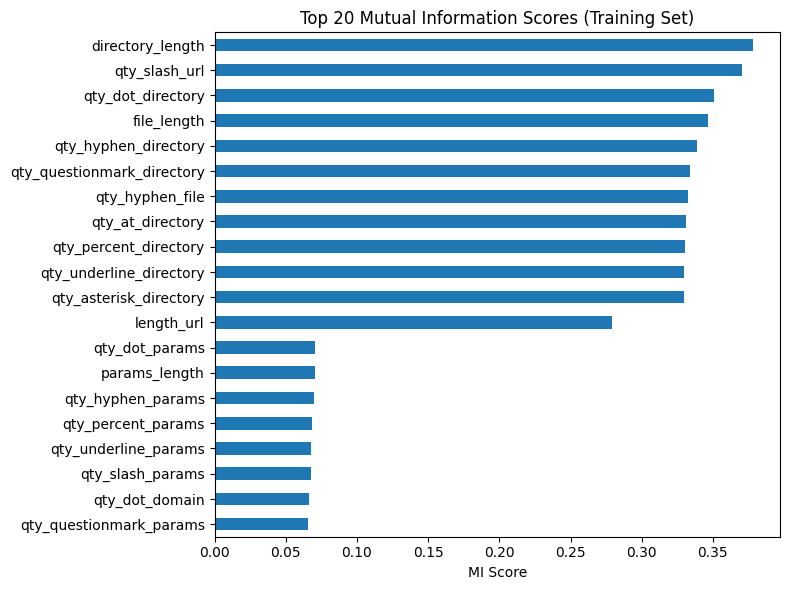

In [16]:
from sklearn.feature_selection import mutual_info_classif
import matplotlib.pyplot as plt

mi_scores = mutual_info_classif(X_train_c, y_train, random_state=RANDOM_STATE)
mi_series = pd.Series(mi_scores, index=X_train_c.columns).sort_values(ascending=False)

display(mi_series.head(20))

plt.figure(figsize=(8, 6))
mi_series.head(20).sort_values().plot(kind="barh")
plt.title("Top 20 Mutual Information Scores (Training Set)")
plt.xlabel("MI Score")
plt.tight_layout()
plt.show()

Top 20 fitur berdasarkan Random Forest Feature Importance:


,0
directory_length,0.146200
length_url,0.079448
qty_slash_url,0.063590
qty_dot_directory,0.061678
qty_questionmark_directory,0.060796
qty_hyphen_directory,0.056381
qty_percent_directory,0.056182
qty_hyphen_file,0.055497
qty_at_directory,0.055183
file_length,0.049669


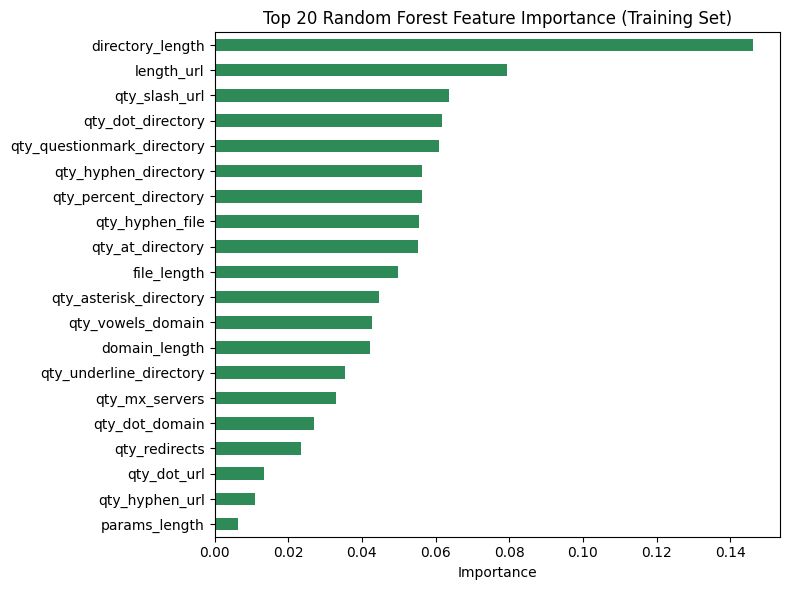

In [17]:
from sklearn.ensemble import RandomForestClassifier

rf_probe = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1)
rf_probe.fit(X_train_c, y_train)

importance_series = pd.Series(
    rf_probe.feature_importances_, index=X_train_c.columns
).sort_values(ascending=False)

print("Top 20 fitur berdasarkan Random Forest Feature Importance:")
display(importance_series.head(20))

plt.figure(figsize=(8, 6))
importance_series.head(20).sort_values().plot(kind="barh", color="seagreen")
plt.title("Top 20 Random Forest Feature Importance (Training Set)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


In [ ]:
TOP_N = 30
SELECTION_MODE = "union"

top_mi = set(mi_series.head(TOP_N).index)
top_rf = set(importance_series.head(TOP_N).index)

if SELECTION_MODE == "union":
    selected_features = sorted(top_mi | top_rf)
elif SELECTION_MODE == "intersection":
    selected_features = sorted(top_mi & top_rf)
else:
    raise ValueError("SELECTION_MODE harus 'union' atau 'intersection'")

print(f"Mode seleksi: {SELECTION_MODE}")
print(f"Jumlah fitur dari Mutual Information (Top {TOP_N}): {len(top_mi)}")
print(f"Jumlah fitur dari RF Importance (Top {TOP_N})     : {len(top_rf)}")
print(f"Jumlah fitur final terpilih                        : {len(selected_features)}")
print()
print("Daftar fitur final:")
print(selected_features)


Mode seleksi: union
Jumlah fitur dari Mutual Information (Top 30): 30
Jumlah fitur dari RF Importance (Top 30)     : 30
Jumlah fitur final terpilih                        : 33

Daftar fitur final:
['directory_length', 'domain_length', 'email_in_url', 'file_length', 'length_url', 'params_length', 'qty_and_url', 'qty_asterisk_directory', 'qty_at_directory', 'qty_at_url', 'qty_dot_directory', 'qty_dot_domain', 'qty_dot_params', 'qty_dot_url', 'qty_equal_url', 'qty_hyphen_directory', 'qty_hyphen_domain', 'qty_hyphen_file', 'qty_hyphen_params', 'qty_hyphen_url', 'qty_mx_servers', 'qty_percent_directory', 'qty_percent_params', 'qty_questionmark_directory', 'qty_questionmark_params', 'qty_redirects', 'qty_slash_params', 'qty_slash_url', 'qty_tld_url', 'qty_underline_directory', 'qty_underline_params', 'qty_underline_url', 'qty_vowels_domain']


In [19]:
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest
from sklearn.model_selection import StratifiedKFold, cross_validate

N_FOLDS = 5
TOP_N = 30 # Explicitly define TOP_N to avoid NameError
K_BEST = min(TOP_N, X_train_c.shape[1])  # jumlah fitur yang dipilih SelectKBest per fold

pipeline = Pipeline([
    ("feature_selection", SelectKBest(score_func=mutual_info_classif, k=K_BEST)),
    ("classifier", RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1))
])

cv = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

cv_results = cross_validate(
    pipeline, X_train_c, y_train,
    cv=cv,
    scoring=["accuracy", "f1", "roc_auc"],
    return_train_score=True,
    n_jobs=-1
)

print(f"Hasil {N_FOLDS}-Fold Cross Validation (feature selection di-refit tiap fold):\n")
for metric in ["accuracy", "f1", "roc_auc"]:
    train_scores = cv_results[f"train_{metric}"]
    val_scores = cv_results[f"test_{metric}"]
    print(f"{metric.upper():10s} | Train: {train_scores.mean():.4f} (+/-{train_scores.std():.4f})"
          f"  |  Validation: {val_scores.mean():.4f} (+/-{val_scores.std():.4f})")

print("\nCatatan: jika skor Train jauh lebih tinggi dari Validation (misal selisih >5-10%),")
print("ini indikasi awal overfitting yang akan dianalisis lebih lanjut di notebook Overfitting Analysis.")

Hasil 5-Fold Cross Validation (feature selection di-refit tiap fold):

ACCURACY   | Train: 0.9734 (+/-0.0032)  |  Validation: 0.9344 (+/-0.0027)
F1         | Train: 0.9609 (+/-0.0048)  |  Validation: 0.9053 (+/-0.0039)
ROC_AUC    | Train: 0.9941 (+/-0.0013)  |  Validation: 0.9746 (+/-0.0012)

Catatan: jika skor Train jauh lebih tinggi dari Validation (misal selisih >5-10%),
ini indikasi awal overfitting yang akan dianalisis lebih lanjut di notebook Overfitting Analysis.


In [23]:
import json

# Re-define variables to ensure they are available in this cell
TOP_N = 30 # From RaDqOFYvBaot
SELECTION_MODE = "union" # From RaDqOFYvBaot

top_mi = set(mi_series.head(TOP_N).index)
top_rf = set(importance_series.head(TOP_N).index)

# Assuming SELECTION_MODE is 'union' as per previous context
# If SELECTION_MODE can vary, it might be better to re-run cell RaDqOFYvBaot or pass it here.
# For now, we'll assume it's 'union' based on the last successful execution.
if SELECTION_MODE == "union":
    selected_features = sorted(top_mi | top_rf)
elif SELECTION_MODE == "intersection":
    selected_features = sorted(top_mi & top_rf)
else:
    raise ValueError("SELECTION_MODE harus 'union' atau 'intersection'")

with open("selected_features.json", "w") as f:
    json.dump(selected_features, f, indent=2)

with open("feature_order.json", "w") as f:
    json.dump(selected_features, f, indent=2)  # urutan fitur ini WAJIB dipakai konsisten saat inferensi di Chrome Extension

# Buat versi train/test set yang sudah hanya berisi fitur terpilih, untuk notebook training
X_train_final = X_train[selected_features].copy()
X_test_final = X_test[selected_features].copy()

X_train_final.assign(**{TARGET_COL: y_train}).to_csv("train_set_selected.csv", index=False)
X_test_final.assign(**{TARGET_COL: y_test}).to_csv("test_set_selected.csv", index=False)

print("File tersimpan:")
print("  - selected_features.json")
print("  - feature_order.json")
print("  - train_set_selected.csv")
print("  - test_set_selected.csv")
print(f"\nJumlah fitur final untuk training: {len(selected_features)}")

File tersimpan:
  - selected_features.json
  - feature_order.json
  - train_set_selected.csv
  - test_set_selected.csv

Jumlah fitur final untuk training: 33
